# Assignment
## Implement calibrator for Tree

* Background: In the Black--Scholes model volatility is a key parameter that determines option price. In a Balanced Binomial Tree (i.e. risk-neutral up step probability $= 0.5$ risk-neutral down step probability $= 0.5$) the same role is played by step size: higher step is like higher volatility, it results in higher option prices. Also, there is a 1-1 correspondence between step size and price if all other parameters are fixed.
* Task: Write a calibrate method which, for a given number of steps parameter, computes the up step size for which a Balanced Binomial Tree model returns the specified price for a given European call. (In practice option prices can be observed in the market, so it makes sense to assume it is given). Demonstrate the calibrate method for various input parameters (same contract with a few different number of steps (dont forget to scale the discount factor to keep interest rates flat); calibrate one step tree for various contracts (different expiries and strike levels, flat interest rate)). Make simple plots to illustrate results.
* Hint: To do it you will need to use a root solver, I recommend using scipy.optimize.minimize.

Ide csak bemásoltam az órán használt függvényeket, ezeket fogom beépíteni a kalibrálós fába is.

In [19]:
import numpy as np
from numpy import dtype
from scipy.optimize import minimize

def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

def create_spot_tree(spot: float, spot_mult_up: float, spot_mult_down: float, steps: int) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

def create_discounted_price_tree(spot_tree: list[list[float]], discount_factor: float, K: float, diag: int = 0) -> list[
    list[float]]:
    S0 = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1] / S0
    spot_mult_down = spot_tree[1][0] / S0
    p_up = ((1 / discount_factor - spot_mult_down) /
            (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]]  #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor ** (steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                               p_down * continuation_value_tree[step + 1][i + 1]
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i + 1] - continuation_value_tree[step + 1][i])
                                       / (spot_tree[step + 1][i + 1] - spot_tree[step + 1][i]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

def calcBalancedDownStep(spot_mult_up: float, discount_factor: float) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

In [125]:
# Minimális változtatásokat csináltam a create_discounted_price_tree függvényben, azt csekkolom jól működik-e
spot = 100
spot_mult_up = 1.2
spot_mult_down = 0.8
steps = 2
discount_factor = 0.95
strike = 100
diag = 1

print("spot_mult_up: " + str('%.3f' %spot_mult_up))
spot_mult_down_balanced = calcBalancedDownStep(spot_mult_up, discount_factor)
print("spot_mult_down: " + str('%.3f' %spot_mult_down_balanced))
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down_balanced, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
print("spot_tree: " + str(spot_tree_readable))
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, 1)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("price tree: " + str(price_tree_readable))

spot_mult_up: 1.200
spot_mult_down: 0.905
spot_tree: [['100.000'], ['90.526', '120.000'], ['81.950', '108.632', '144.000']]
risk-neutral measure: 
('0.500', '0.500')
delta: 
[['0.674'], ['0.292', '0.902']]
price tree: [['13.822'], ['3.895', '23.750'], ['0.000', '7.790', '39.710']]


In [132]:
def price_from_calibrated_u(u: float, spot: float, K: float, discount_factor: float, steps: int) -> float:
    d = calcBalancedDownStep(u, discount_factor)
    spot_tree = create_spot_tree(spot, u, d, steps)
    price_tree = create_discounted_price_tree(spot_tree, discount_factor, K)

    return price_tree[0][0]

def calibrated_tree(market_price: float, spot: float, K: float, discount_factor: float, steps: int,
                    initial_u_guess: float = None) -> float:

    def f_function(u_guess):
        option_price = price_from_calibrated_u(u_guess[0], spot, K, discount_factor, steps)
        return (option_price - market_price) ** 2 # különbség négyzetét minimalizálom

    u_lower_bound = 1 / discount_factor
    if initial_u_guess is not None:
        if initial_u_guess <= u_lower_bound:
            print(f"Warning: Your guess ({initial_u_guess:.2f}) is <= (1+r)^dt ({u_lower_bound:.2f}). The optimizer might struggle.")
            initial_guess = [initial_u_guess]
        else:
            initial_guess = [u_lower_bound * 1.05] # felfelé lépés nagyobb legyen, mint (1+r)^dt

    bounds = [(u_lower_bound + 1e-6, None)] # u > (1+r)^dt
    result = minimize(f_function, x0=initial_guess, bounds=bounds, method='L-BFGS-B') # dokumentáció alapján, ha nem adok meg semmit, akkor is BFGS / L-BFGS-B / SLSQP vmelyikét választja a függvény default-ként

    if not result.success:
        print(f"Warning: Calibration failed for K={K}. {result.message}")

    return result.x[0]

In [133]:
import numpy as np
from scipy.stats import norm
from typing import Dict, List, Union

"""The pricing function of European call option"""
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray],
                           output: str = 'price') -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0
    assert T > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    derN_d1 = norm.pdf(d1_vec)

    output = output.lower()
    if output == 'price':
        return N_d1_vec * S0 - K * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'delta':
        return N_d1_vec
    elif output == 'vega':
        return S0 * derN_d1 * T**0.5
    elif output == 'theta':
        return (-S0 * derN_d1 * sigma / (2 * T**0.5)) - (r * K * np.exp((-1.0)*r*T) * N_d2_vec)
    elif output == 'rho':
        return K * T * np.exp((-1.0)*r*T) * N_d2_vec
    elif output == 'gamma':
        return derN_d1 / (S0 * sigma * T**0.5)
    else:
        raise ValueError(f"Invalid output type '{output}'."
                         "Choose from: 'price', 'delta', 'vega', 'theta', 'rho', 'gamma'.")

# Itt letesztelem dummy adatokkal jól működik-e, rendes BS ár generáláshoz, bemásoltam a függvényt, amit az előző háziban csináltam
S0 = 100
K = 100
sigma = 0.1
u_guess = 1.2
steps = 5
r = 0.10
T = 1
dt = T/steps
DF = 1/((1+r)**dt)

call_mkt_price = black_scholes_eur_call(r=r, T=T, S0=S0, sigma=sigma, K=K, output='price')
u_calib = calibrated_tree(market_price=call_mkt_price, spot=S0, K=K, discount_factor=DF, steps=steps, initial_u_guess=u_guess)
model_price = price_from_calibrated_u(u=u_calib, spot=S0, K=K, discount_factor=DF, steps=steps)
print(f'BS price = {call_mkt_price}\ncalibrated price = {model_price}')

BS price = 10.308150925634422
calibrated price = 10.308150795929203


Most pedig nézzük rendes, live adatokkal

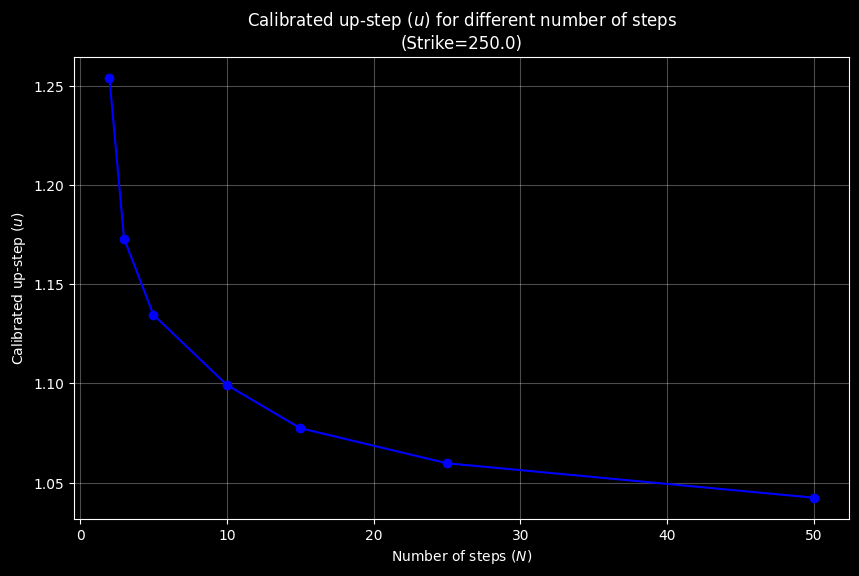

In [119]:
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt

ticker = yf.Ticker('AAPL')
spot_price = ticker.history(period="1d")['Close'].iloc[0]

'''Same contract with different number of steps'''
expirations = ticker.options
target_expiry = expirations[17] # kiválasztottam csak egyet, ami kb közel volt az 1 évhez
opt_chain = ticker.option_chain(target_expiry)
calls = opt_chain.calls

expiry_date = datetime.strptime(target_expiry, '%Y-%m-%d')
days_to_expiry = (expiry_date - datetime.now()).days
T = days_to_expiry / 365
r = 0.05

atm_call = calls.iloc[(calls['strike'] - spot_price).abs().argsort()[:1]].iloc[0]
K_atm = atm_call['strike'] # ezt is lehet random választani, én próbáltam a spot price-hoz közelit keresni
market_price_atm = atm_call['lastPrice']

steps_list = [2,3,5,10,15,25,50]
calibrated_u_steps = []
for N in steps_list:
    dt = T / N
    DF = 1/((1+r)**dt)
    u_calibrated = calibrated_tree(market_price=market_price_atm, spot=spot_price, K=K_atm, discount_factor=DF, steps=N,
                                   initial_u_guess=1.2)
    calibrated_u_steps.append(u_calibrated)

plt.figure(figsize=(10, 6))
plt.plot(steps_list, calibrated_u_steps, marker='o', linestyle='-', color='blue')
plt.title(f'Calibrated up-step ($u$) for different number of steps\n(Strike={K_atm})')
plt.xlabel('Number of steps ($N$)')
plt.ylabel('Calibrated up-step ($u$)')
plt.grid(True, alpha=0.3)
plt.show()

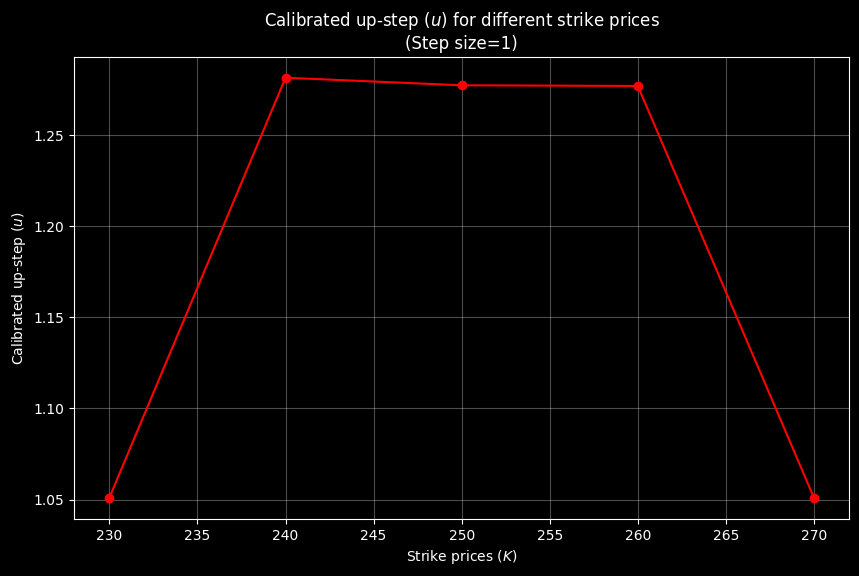

[1.0510220976511846,
 1.2815640016851446,
 1.2774080252229891,
 1.277046183722716,
 1.0510138541876988]

In [120]:
'''One step tree for various strike prices'''
filtered_calls_K = calls[(calls['strike'] > spot_price * 0.90) & (calls['strike'] < spot_price * 1.10)] # olyan strike-okat választok, amik közel vannak a spot price-hoz, ezek liquid-ebbek
strikes = filtered_calls_K['strike'].values
mkt_prices_K = filtered_calls_K['lastPrice'].values

calibrated_u_strikes = []
for K, price in zip(strikes, mkt_prices_K):
    u_calibrated_K = calibrated_tree(market_price=price, spot=spot_price, K=K, discount_factor=DF, steps=1, initial_u_guess=1.2)
    calibrated_u_strikes.append(u_calibrated_K)

plt.figure(figsize=(10, 6))
plt.plot(strikes, calibrated_u_strikes, marker='o', linestyle='-', color='red')
plt.title('Calibrated up-step ($u$) for different strike prices\n(Step size=1)')
plt.xlabel('Strike prices ($K$)')
plt.ylabel('Calibrated up-step ($u$)')
plt.grid(True, alpha=0.3)
plt.show()
calibrated_u_strikes

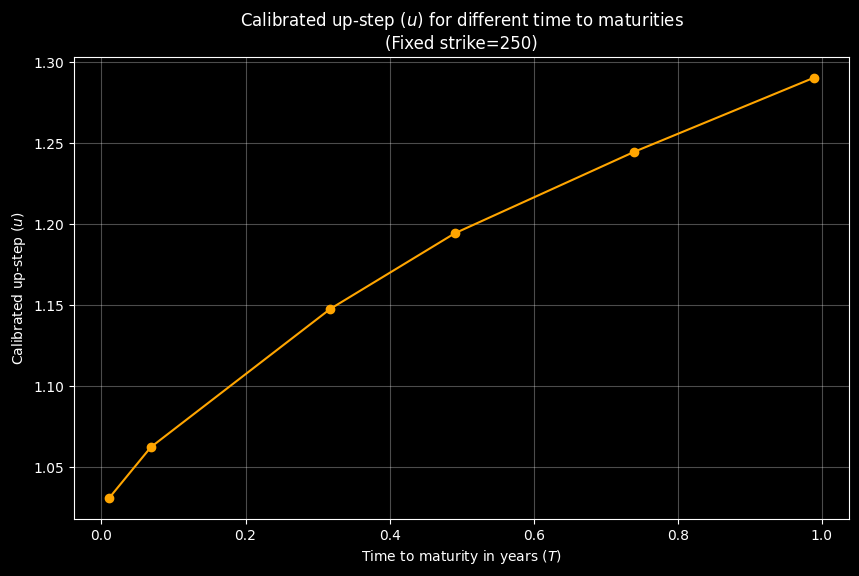

In [128]:
'''One step tree for various time to maturities'''
specific_strike = 250
r = 0.05
exp_list = [expirations[2], expirations[5], expirations[10], expirations[12], expirations[15], expirations[17]] # itt is csak random kiválasztottam párat 1 éven belüli lejáratok közül
calibrated_u_maturities = []
T_list = []
market_price_T = []

for exp in exp_list:
    expiry_date = datetime.strptime(exp, '%Y-%m-%d')
    days_to_expiry = (expiry_date - datetime.now()).days
    current_T = days_to_expiry / 365

    opt_chain = ticker.option_chain(exp)
    calls = opt_chain.calls
    filtered_call_T = calls[calls['strike'] == specific_strike].iloc[0]

    if not filtered_call_T.empty:
        mkt_price = filtered_call_T['lastPrice']
        current_DF = 1/((1+r)**current_T)

        u_calibrated_T = calibrated_tree(market_price=mkt_price, spot=spot_price, K=specific_strike,
                                         discount_factor=current_DF, steps=1, initial_u_guess=1.2)
        calibrated_u_maturities.append(u_calibrated_T)
        T_list.append(current_T)
        market_price_T.append(mkt_price)

plt.figure(figsize=(10, 6))
plt.plot(T_list, calibrated_u_maturities, marker='o', linestyle='-', color='orange')
plt.title(f'Calibrated up-step ($u$) for different time to maturities\n(Fixed strike={specific_strike})')
plt.xlabel('Time to maturity in years ($T$)')
plt.ylabel('Calibrated up-step ($u$)')
plt.grid(True, alpha=0.3)
plt.show()
